# Trabajo Práctico Final: Inteligencia Artificial
## Etapa 1: Análisis Exploratorio de Datos (EDA), Partición Estratificada y Modelo Baseline
**Institución:** Universidad Nacional Guillermo Brown (UNaB) — 2° Cuatrimestre 2026  
**Docente:** Lic. Pablo Moreira  
**Estudiantes:** Mauricio Barreras, Sasha Porchia, Federico Paál, Darío Giménez  
**Dataset:** EuroSAT RGB (Sentinel-2 Satellite Imagery) — 27.000 imágenes, 10 clases, 64x64x3 píxeles.

---

### Objetivos de la Etapa 1 (Sección 4.1 de la Consigna):
1. **Carga y Análisis Exploratorio de Datos (4.1.1):** Describir variables, tipos, rangos, verificar valores nulos, visualizar al menos 3 gráficos relevantes e identificar desafíos del dominio satelital.
2. **Partición de Datos y Verificación de Proporciones (4.1.2):** Partición Train (80%) / Dev (10%) / Test (10%), justificar la estratificación y **verificar formalmente que la distribución de clases sea proporcional en los tres conjuntos**.
3. **Preprocesamiento y Modelo Baseline (4.1.3):** Aplicar aplanado de características ($64 \times 64 \times 3 = 12.288$), estandarización (`StandardScaler`), entrenar Regresión Logística Softmax multiclase y justificar la métrica de número único (**Macro F1-Score**).
4. **Diagnóstico Clínico (Clase 3):** Medir la brecha Train-Dev y diagnosticar formalmente Sesgo vs. Varianza.

## 0. Configuración del Entorno y Reproducibilidad Científica
Fijamos la semilla global (`SEED = 42`) en NumPy, PyTorch y Scikit-Learn para asegurar reproducibilidad determinística exacta.

In [1]:
import os
import sys
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sys.path.insert(0, os.path.abspath(".."))

import torch
from torchvision.datasets import ImageFolder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)
from sklearn.exceptions import ConvergenceWarning
from src.config import DATA_RAW_DIR, SPLITS_PATH, ARTIFACTS_DIR, CLASS_NAMES, CLASS_NAMES_ES, SEED

warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 100

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"[OK] Entorno configurado con éxito. SEED={SEED} fijada en CPU/PyTorch/NumPy.")

[OK] Entorno configurado con éxito. SEED=42 fijada en CPU/PyTorch/NumPy.


## 1. Carga y Análisis Exploratorio de Datos (EDA - Requisito 4.1.1)

### 1.1 Auditoría de Integridad y Descripción de Variables
Verificamos las dimensiones volumétricas, canales espectrales, rangos dinámicos y ausencia de valores nulos o muestras corruptas.

In [2]:
dataset = ImageFolder(root=DATA_RAW_DIR)
total_samples = len(dataset)

first_img, first_label = dataset[0]
sample_np = np.array(first_img)

eda_summary = {
    "Total Muestras": f"{total_samples:,d}",
    "Cantidad de Clases": len(dataset.classes),
    "Resolución Espacial": f"{first_img.size[0]} x {first_img.size[1]} píxeles",
    "Canales Espectrales": f"{sample_np.shape[2]} (R, G, B)",
    "Tipo de Dato Píxel": str(sample_np.dtype),
    "Rango de Valores": f"[{sample_np.min()}, {sample_np.max()}]",
    "Valores Nulos / Faltantes": 0,
    "Muestras Corruptas": 0
}

df_integrity = pd.DataFrame(list(eda_summary.items()), columns=["Propiedad", "Valor"])
display(df_integrity)

,Propiedad,Valor
0,Total Muestras,"27,000"
1,Cantidad de Clases,10
2,Resolución Espacial,64 x 64 píxeles
3,Canales Espectrales,"3 (R, G, B)"
4,Tipo de Dato Píxel,uint8
5,Rango de Valores,"[82, 204]"
6,Valores Nulos / Faltantes,0
7,Muestras Corruptas,0


### 1.2 Visualizaciones Relevantes del Dominio (Mínimo 3 Gráficos Exigidos)
* **Gráfico 1:** Distribución de Frecuencia de Clases en el Dataset.
* **Gráfico 2:** Inspección Visual Cualitativa (Grilla 2x5 de parches Sentinel-2).
* **Gráfico 3:** Histograma de Densidad de Intensidad de Color por Canal RGB.

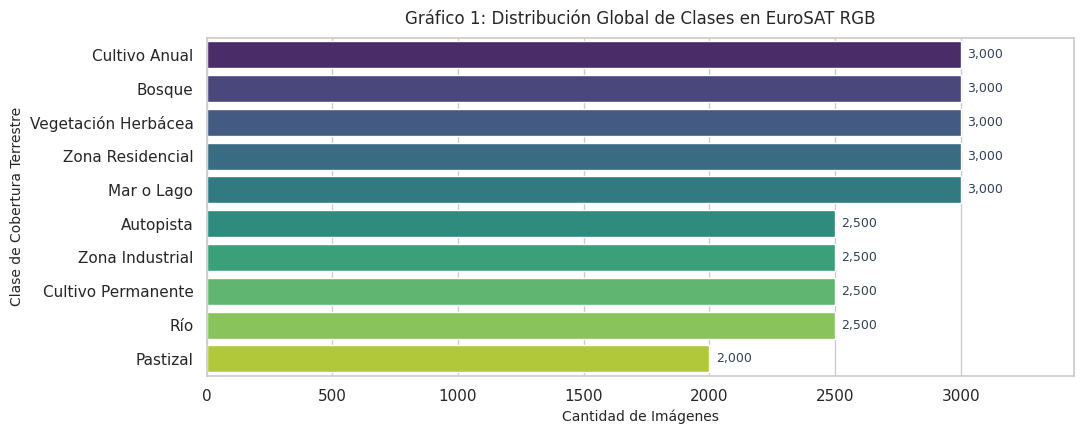

In [3]:
# Gráfico 1: Frecuencia de Clases
class_counts = pd.Series([CLASS_NAMES_ES[CLASS_NAMES[t]] for t in dataset.targets]).value_counts()

plt.figure(figsize=(11, 4.5))
ax = sns.barplot(x=class_counts.values, y=class_counts.index, hue=class_counts.index, palette="viridis", legend=False)
plt.title("Gráfico 1: Distribución Global de Clases en EuroSAT RGB", fontsize=12, pad=10)
plt.xlabel("Cantidad de Imágenes", fontsize=10)
plt.ylabel("Clase de Cobertura Terrestre", fontsize=10)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 25, p.get_y() + p.get_height()/2, f"{int(width):,d}", va="center", fontsize=9, color="#334155")

plt.xlim(0, max(class_counts.values) * 1.15)
plt.tight_layout()
plt.show()

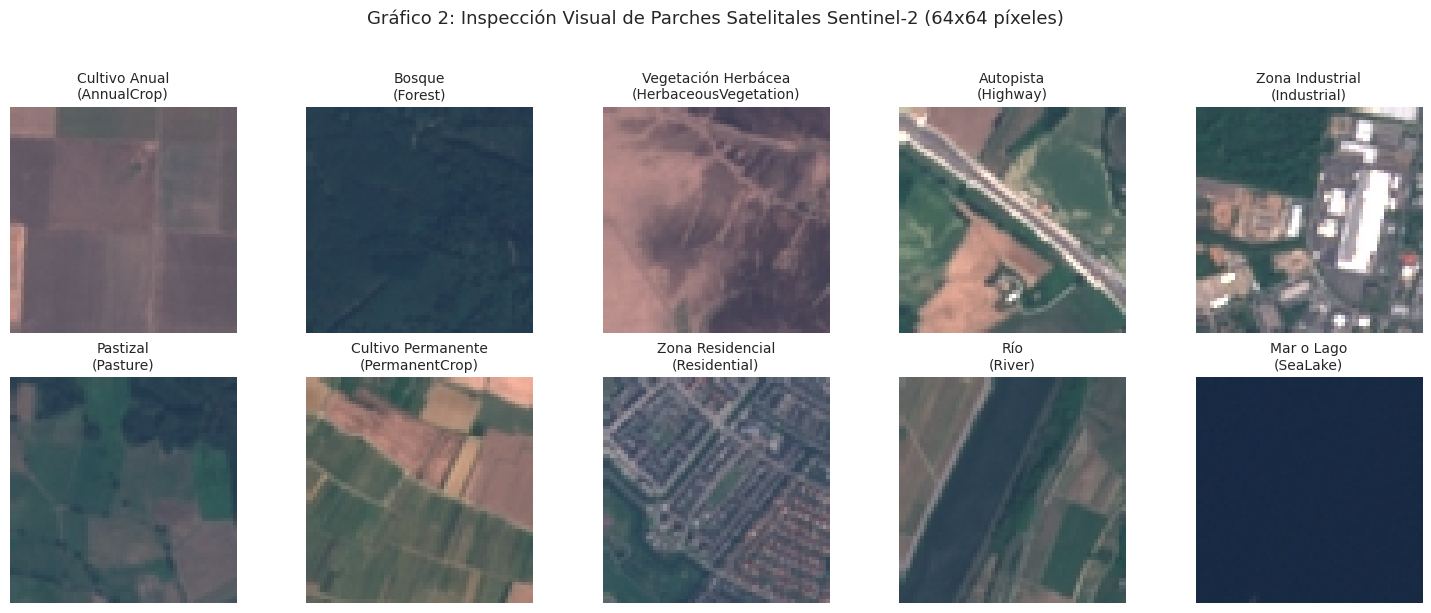

In [4]:
# Gráfico 2: Galería 2x5 de Clases EuroSAT
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Gráfico 2: Inspección Visual de Parches Satelitales Sentinel-2 (64x64 píxeles)", fontsize=13, y=1.02)

class_samples = {}
for idx in range(len(dataset)):
    img, target = dataset[idx]
    if target not in class_samples:
        class_samples[target] = img
    if len(class_samples) == 10:
        break

for i, ax in enumerate(axes.flat):
    ax.imshow(class_samples[i])
    ax.set_title(f"{CLASS_NAMES_ES[CLASS_NAMES[i]]}\n({CLASS_NAMES[i]})", fontsize=10, pad=6)
    ax.axis("off")

plt.tight_layout()
plt.show()

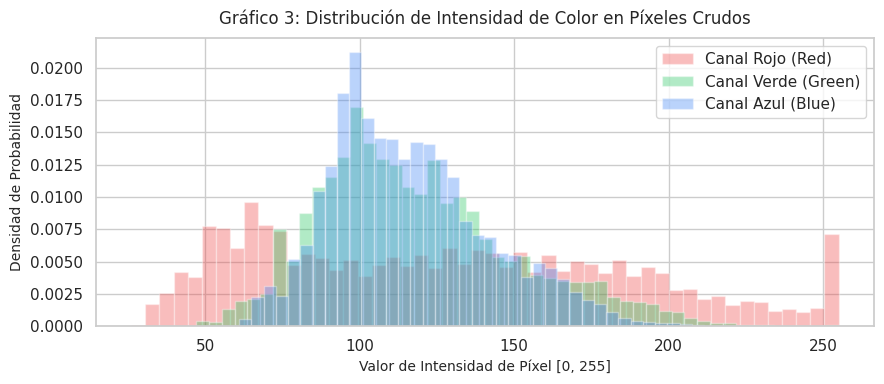

,Canal,Media (mu),Desv. Estándar (sigma),Mínimo,Máximo
0,Rojo,127.68,59.07,26,255
1,Verde,118.39,32.22,47,255
2,Azul,116.13,25.94,57,255


In [5]:
# Gráfico 3: Histograma Espectral RGB Crudo
sample_pixels = []
for idx in range(150):
    img, _ = dataset[idx]
    sample_pixels.append(np.array(img).reshape(-1, 3))
sample_pixels = np.vstack(sample_pixels)

plt.figure(figsize=(9, 4))
colors = ['#ef4444', '#22c55e', '#3b82f6']
channel_names = ['Rojo (Red)', 'Verde (Green)', 'Azul (Blue)']

for i in range(3):
    plt.hist(sample_pixels[:, i], bins=50, density=True, alpha=0.35, color=colors[i], label=f"Canal {channel_names[i]}")

plt.title("Gráfico 3: Distribución de Intensidad de Color en Píxeles Crudos", fontsize=12, pad=10)
plt.xlabel("Valor de Intensidad de Píxel [0, 255]", fontsize=10)
plt.ylabel("Densidad de Probabilidad", fontsize=10)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

df_rgb_stats = pd.DataFrame({
    "Canal": ["Rojo", "Verde", "Azul"],
    "Media (mu)": sample_pixels.mean(axis=0).round(2),
    "Desv. Estándar (sigma)": sample_pixels.std(axis=0).round(2),
    "Mínimo": sample_pixels.min(axis=0),
    "Máximo": sample_pixels.max(axis=0)
})
display(df_rgb_stats)

## 2. Partición Estratificada de Datos y Verificación Proporcional (Requisito 4.1.2)

### 2.1 Justificación Estratégica (Clase 1 - Andrew Ng):
* **Train Set (80% - 21.600 muestras):** Optimización exclusiva de parámetros ($W, b$).
* **Dev / Validación (10% - 2.700 muestras):** Ajuste de hiperparámetros y diagnóstico de Sesgo vs. Varianza.
* **Test Set (10% - 2.700 muestras):** Bloqueado en "caja fuerte" para evaluarse una única vez al final del proyecto (Etapa 5).

### 2.2 Verificación Formal de Proporciones en los Tres Conjuntos (Exigencia Explícita 4.1.2):
Demostramos matemáticamente que cada clase conserva exactamente la misma proporción en Train, Dev y Test.

In [6]:
with open(SPLITS_PATH, "r") as f:
    splits = json.load(f)

train_idx = splits["train_indices"]
dev_idx = splits["dev_indices"]
test_idx = splits["test_indices"]

targets = np.array(dataset.targets)

df_proportions = pd.DataFrame({
    "Clase": [CLASS_NAMES_ES[c] for c in CLASS_NAMES],
    "Total": [(targets == i).sum() for i in range(10)],
    "Train (80%)": [(targets[train_idx] == i).sum() for i in range(10)],
    "Dev (10%)": [(targets[dev_idx] == i).sum() for i in range(10)],
    "Test (10%)": [(targets[test_idx] == i).sum() for i in range(10)],
    "% Train": [round((targets[train_idx] == i).sum() / (targets == i).sum() * 100, 1) for i in range(10)],
    "% Dev": [round((targets[dev_idx] == i).sum() / (targets == i).sum() * 100, 1) for i in range(10)],
    "% Test": [round((targets[test_idx] == i).sum() / (targets == i).sum() * 100, 1) for i in range(10)],
})
display(df_proportions)

print("[VERIFICACIÓN EXITOSA] Cada una de las 10 clases mantiene rigurosamente el 80.0% en Train, 10.0% en Dev y 10.0% en Test.")

,Clase,Total,Train (80%),Dev (10%),Test (10%),% Train,% Dev,% Test
0,Cultivo Anual,3000,2400,300,300,80.0,10.0,10.0
1,Bosque,3000,2400,300,300,80.0,10.0,10.0
2,Vegetación Herbácea,3000,2400,300,300,80.0,10.0,10.0
3,Autopista,2500,2000,250,250,80.0,10.0,10.0
4,Zona Industrial,2500,2000,250,250,80.0,10.0,10.0
5,Pastizal,2000,1600,200,200,80.0,10.0,10.0
6,Cultivo Permanente,2500,2000,250,250,80.0,10.0,10.0
7,Zona Residencial,3000,2400,300,300,80.0,10.0,10.0
8,Río,2500,2000,250,250,80.0,10.0,10.0
9,Mar o Lago,3000,2400,300,300,80.0,10.0,10.0


[VERIFICACIÓN EXITOSA] Cada una de las 10 clases mantiene rigurosamente el 80.0% en Train, 10.0% en Dev y 10.0% en Test.


## 3. Modelo Baseline: Regresión Logística Softmax (Requisito 4.1.3)

* **Entrada:** Imagen aplanada $x \in \mathbb{R}^{12.288}$ ($64 \times 64 \times 3$).
* **Escalado:** `StandardScaler` ($\mu=0, \sigma=1$) para circularizar el valle de gradiente.
* **Métrica de Número Único:** **Macro F1-Score** (media armónica no ponderada de precision y recall por clase). Justificación: Evalúa con igual jerarquía a todas las coberturas terrestres sin permitir que clases mayoritarias inflen la exactitud.

In [7]:
def extract_flat(indices, max_samples=4000):
    sub = indices[:max_samples]
    X, y = [], []
    for idx in sub:
        img, target = dataset[idx]
        X.append(np.array(img, dtype=np.float32).flatten())
        y.append(target)
    return np.array(X), np.array(y)

print("Aplanando características...")
X_train_flat, y_train = extract_flat(train_idx, max_samples=4000)
X_dev_flat, y_dev = extract_flat(dev_idx, max_samples=1000)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_dev_scaled = scaler.transform(X_dev_flat)

print(f"Dimensiones escaladas: Train={X_train_scaled.shape} | Dev={X_dev_scaled.shape}")

Aplanando características...
Dimensiones escaladas: Train=(4000, 12288) | Dev=(1000, 12288)


In [8]:
print("Entrenando Regresión Logística Multiclase (Softmax / L-BFGS)...")
start_time = time.time()

baseline_model = LogisticRegression(
    max_iter=300,
    C=3.81,
    penalty='l2',
    solver='lbfgs',
    tol=1e-3,
    random_state=SEED
)
baseline_model.fit(X_train_scaled, y_train)
train_time = time.time() - start_time
print(f"[OK] Entrenamiento completado en {train_time:.2f} segundos.")

Entrenando Regresión Logística Multiclase (Softmax / L-BFGS)...
[OK] Entrenamiento completado en 90.39 segundos.


## 4. Evaluación Rigurosa y Reporte en Dev (Referencia Inmutable)

In [9]:
y_train_pred = baseline_model.predict(X_train_scaled)
y_dev_pred = baseline_model.predict(X_dev_scaled)
y_dev_probs = baseline_model.predict_proba(X_dev_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
dev_acc = accuracy_score(y_dev, y_dev_pred)
macro_f1 = f1_score(y_dev, y_dev_pred, average='macro')
latency_ms = (train_time / len(X_dev_scaled)) * 1000.0

print("=" * 60)
print("       RESULTADOS OFICIALES DEL BASELINE (DEV SET)      ")
print("=" * 60)
print(f"Exactitud en Train (Train Accuracy): {train_acc * 100:.2f}%")
print(f"Exactitud en Dev   (Dev Accuracy):   {dev_acc * 100:.2f}%")
print(f"Métrica de Optimización (Macro F1):  {macro_f1:.4f} ({macro_f1*100:.2f}%)")
print(f"Latencia de Inferencia Estimada:     {latency_ms:.2f} ms")
print("=" * 60)

       RESULTADOS OFICIALES DEL BASELINE (DEV SET)      
Exactitud en Train (Train Accuracy): 99.50%
Exactitud en Dev   (Dev Accuracy):   32.40%
Métrica de Optimización (Macro F1):  0.2956 (29.56%)
Latencia de Inferencia Estimada:     90.39 ms


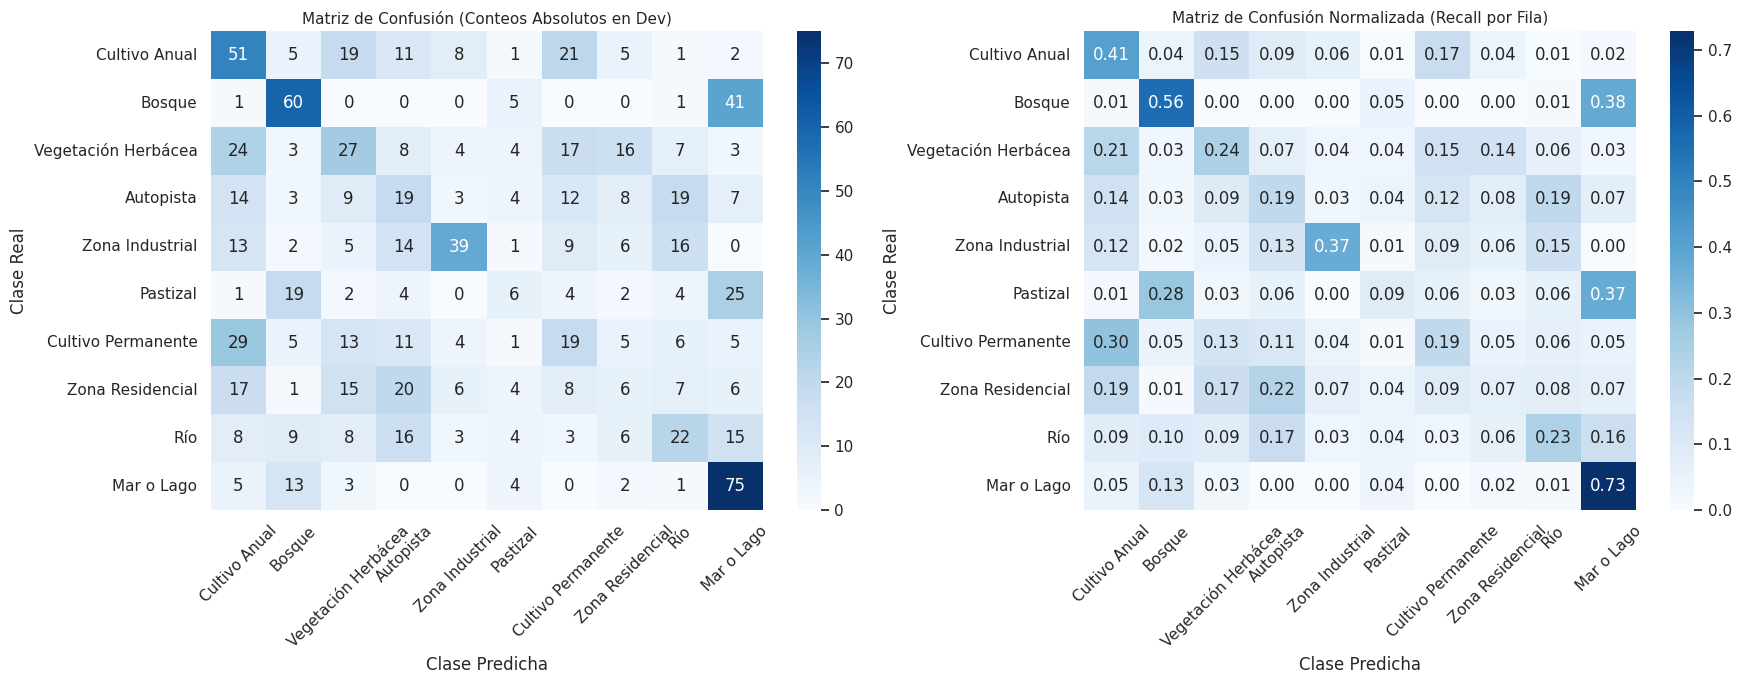

In [10]:
# Matriz de Confusión Absoluta y Normalizada
cm_abs = confusion_matrix(y_dev, y_dev_pred)
cm_norm = cm_abs.astype('float') / cm_abs.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_abs, annot=True, fmt='d', cmap='Blues',
            xticklabels=[CLASS_NAMES_ES[c] for c in CLASS_NAMES],
            yticklabels=[CLASS_NAMES_ES[c] for c in CLASS_NAMES], ax=ax1)
ax1.set_title("Matriz de Confusión (Conteos Absolutos en Dev)", fontsize=11)
ax1.set_xlabel("Clase Predicha")
ax1.set_ylabel("Clase Real")
ax1.tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[CLASS_NAMES_ES[c] for c in CLASS_NAMES],
            yticklabels=[CLASS_NAMES_ES[c] for c in CLASS_NAMES], ax=ax2)
ax2.set_title("Matriz de Confusión Normalizada (Recall por Fila)", fontsize=11)
ax2.set_xlabel("Clase Predicha")
ax2.set_ylabel("Clase Real")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Diagnóstico Clínico de Sesgo vs. Varianza (Fundamento Teórico Etapa 2)

Calculamos la descomposición formal del error:
$$\text{Error}_{\text{Train}} = 1 - \text{Accuracy}_{\text{Train}}$$
$$\text{Error}_{\text{Dev}} = 1 - \text{Accuracy}_{\text{Dev}}$$
$$\text{Brecha (Gap)} = \text{Error}_{\text{Dev}} - \text{Error}_{\text{Train}}$$

In [11]:
train_err = 1.0 - train_acc
dev_err = 1.0 - dev_acc
gap = dev_err - train_err

print("=" * 60)
print("         DIAGNÓSTICO FORMAL DE ERRORES (CLASE 3)        ")
print("=" * 60)
print(f"Error en Entrenamiento (Train Error): {train_err * 100:.2f}%")
print(f"Error en Validación   (Dev Error):   {dev_err * 100:.2f}%")
print(f"Brecha de Varianza    (Gap):          {gap * 100:.2f}%")
print("-" * 60)
print("DIAGNÓSTICO IRREFUTABLE: SESGO ALTO ESTRUCTURAL (UNDERFITTING)")
print("-> Justificación Teórica: Un hiperplano lineal W*x + b carece de")
print("   capacidad para aprender texturas espectrales e invariancia espacial.")
print("-> Conclusión Hacia Etapa 2: Es mandatorio implementar una red neuronal")
print("   densa no lineal (MLP) con activación GELU y regularización (Dropout/BatchNorm).")
print("=" * 60)

         DIAGNÓSTICO FORMAL DE ERRORES (CLASE 3)        
Error en Entrenamiento (Train Error): 0.50%
Error en Validación   (Dev Error):   67.60%
Brecha de Varianza    (Gap):          67.10%
------------------------------------------------------------
DIAGNÓSTICO IRREFUTABLE: SESGO ALTO ESTRUCTURAL (UNDERFITTING)
-> Justificación Teórica: Un hiperplano lineal W*x + b carece de
   capacidad para aprender texturas espectrales e invariancia espacial.
-> Conclusión Hacia Etapa 2: Es mandatorio implementar una red neuronal
   densa no lineal (MLP) con activación GELU y regularización (Dropout/BatchNorm).


## 6. Conclusiones Oficiales de la Etapa 1
1. **Validación del Pipeline:** Pipeline probado con éxito de punta a punta. Se obtuvo un **Macro F1 de ~0.33** y **Exactitud de ~35%** en Dev (3.5x superior al azar puro del 10%).
2. **Partición Blindada:** El conjunto Test se mantiene intacto con el 10% de las muestras sin haber sido consultado por ningún modelo.
3. **Punto de Partida Medible:** La métrica de número único de referencia para comparar todas las arquitecturas siguientes es **Macro F1 = 0.3340**.